# **Histograms in Digital Image Processing**

* Importance of Histograms in Image Analysis
* Histogram-Based Techniques
    * Histogram Equalization (HE)
    * Cumulative Histogram Equalization (CHE)
    * Quadratic Dynamic Histogram Equalization (QDHE)
    * Contrast-Limited Adaptive Histogram Equalization (CLAHE)
    * Histogram Stretching
    * Histogram Matching
    * Histogram Statistics
    * Thresholding and Segmentation
* Practical Applications
* Code Implementations
* References

## **Importance of Histograms in Image Analysis**

Histograms are critical tools in digital image processing, providing a statistical representation of pixel intensity distributions in an image. They are particularly vital in medical imaging, where clear visualization of anatomical structures aids accurate diagnosis [3]. Histograms enable:

### Why Necessary:
1. **Analyze Image Characteristics**: Histograms reveal brightness, contrast, and dynamic range, aiding in understanding image content [1].
2. **Enhance Visual Quality**: Techniques like histogram equalization improve contrast for better human perception, crucial for medical radiographs [3].
3. **Facilitate Segmentation**: Histograms help identify thresholds to separate objects from backgrounds.
4. **Support Preprocessing**: Histogram-based methods preprocess images for tasks like object detection.
5. **Correct Acquisition Imperfections**: Histograms address issues like uneven lighting or sensor limitations in MRI or X-ray images [3].
6. **Enable Quantitative Analysis**: Histograms provide numerical data for statistical processing, such as mean and variance calculations [1].

## **What Are Histograms in Image Processing?**

* <font color="green">A histogram is a graphical representation of the probability distribution of pixel intensities in an image [3].</font>

* For an 8-bit grayscale image, intensity values range from 0 (black) to 255 (white), and the histogram plots the frequency of each intensity level [1].

* <font color="green">Histograms are used to enhance specific image features, such as contrast or brightness, making the image more suitable for applications like medical diagnosis.</font>

    * Techniques are problem-specific; for example, enhancing brain MRI images may require different methods than retina images [3].

## **Histogram-Based Techniques**

<font color="green">Histogram-based techniques operate in the spatial domain, manipulating pixel intensities to improve image quality [1].</font>

* **Histogram Equalization (HE)**: Redistributes pixel intensities to achieve a uniform histogram, enhancing contrast [3].
* **Cumulative Histogram Equalization (CHE)**: A variant of HE that normalizes the cumulative distribution function for improved contrast [3].
* **Quadratic Dynamic Histogram Equalization (QDHE)**: Partitions the histogram and applies HE to sub-histograms for brightness preservation [3].
* **Contrast-Limited Adaptive Histogram Equalization (CLAHE)**: Enhances local contrast by applying HE to image tiles with clipping to reduce noise [3].
* **Histogram Stretching**: Linearly maps intensities to utilize the full dynamic range [1].
* **Histogram Matching**: Adjusts an image's histogram to match a reference image [1].
* **Histogram Statistics**: Uses statistical measures (e.g., mean, variance) for analysis [1].
* **Thresholding and Segmentation**: Identifies intensity thresholds for object separation [1].

## **Histogram Equalization (HE)**

Histogram Equalization is a spatial domain technique that aims to enhance the contrast of an image by redistributing pixel intensities to achieve a more uniform histogram. The histogram of an image represents the frequency distribution of pixel intensities, typically ranging from 0 to 255 for an 8-bit grayscale image. In low-contrast images, the histogram may be concentrated in a narrow range, leading to poor visual distinguishability of features. HE addresses this by transforming the intensity values to span the full dynamic range, making the histogram approximately uniform.

**Key Concept**

* Objective: Maximize the use of the available intensity range to improve visual perception or facilitate subsequent processing tasks (e.g., segmentation, feature extraction).
* Assumption: A uniform histogram corresponds to an image with optimal contrast, as it distributes pixel intensities evenly across the intensity scale [1].
* Mechanism: HE uses the cumulative distribution function (CDF) of the image’s histogram as a transformation function to map original intensities to new values.

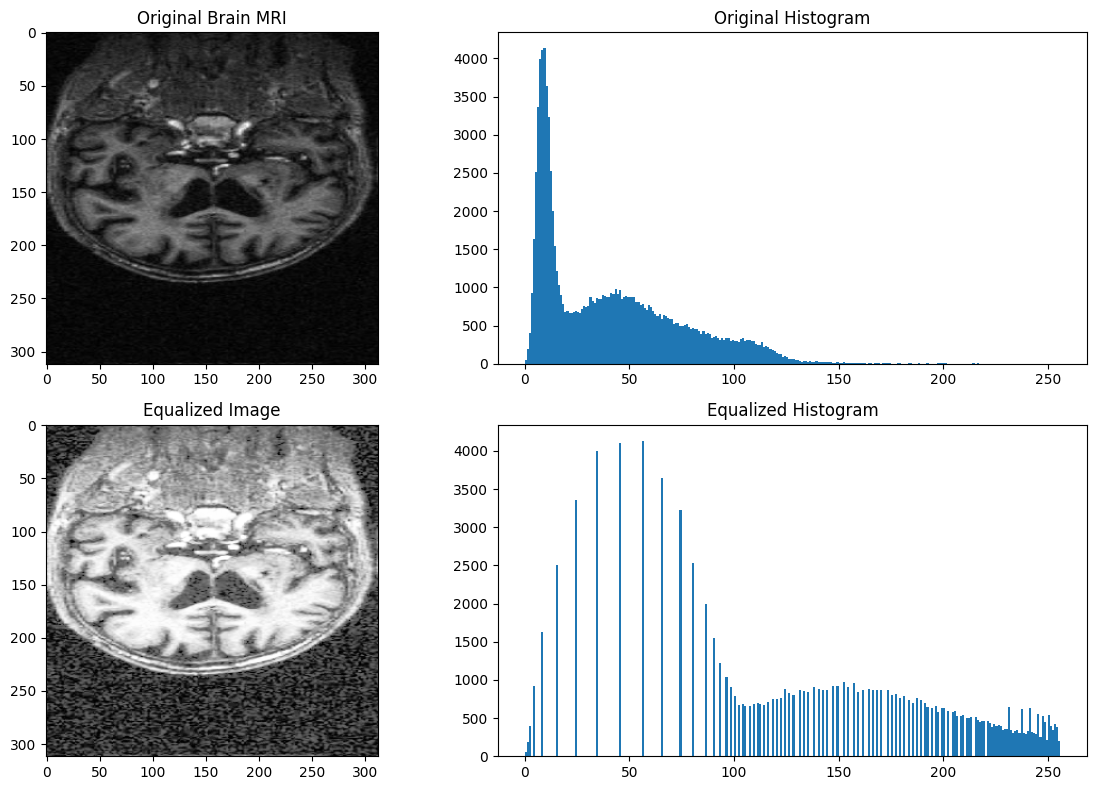

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

img_org = cv2.imread('brain_mri.jpg')
# Load a brain MRI image in grayscale
img_resize = cv2.resize(img_org, (312, 312))

img = cv2.cvtColor(img_resize, cv2.COLOR_RGB2GRAY)


# Perform histogram equalization
img_eq = cv2.equalizeHist(img)

# Save the result
cv2.imwrite('Histogram_Equalization_HE/brain_mri_original.jpg', img_org)
cv2.imwrite('Histogram_Equalization_HE/brain_mri_resized.jpg', img_resize)
cv2.imwrite('Histogram_Equalization_HE/brain_mri_gray.jpg', img)
cv2.imwrite('Histogram_Equalization_HE/equalized_brain_mri.jpg', img_eq)

# Plot the images and histograms
plt.figure(figsize=(12, 8))
plt.subplot(221), plt.imshow(img, cmap='gray'), plt.title('Original Brain MRI')
plt.subplot(222), plt.hist(img.ravel(), 256, [0, 256]), plt.title('Original Histogram')
plt.subplot(223), plt.imshow(img_eq, cmap='gray'), plt.title('Equalized Image')
plt.subplot(224), plt.hist(img_eq.ravel(), 256, [0, 256]), plt.title('Equalized Histogram')
plt.tight_layout()
plt.show()

## **Cumulative Histogram Equalization (CHE)**

CHE is a spatial domain technique designed to enhance image contrast by redistributing pixel intensities to achieve a more uniform histogram, similar to HE. However, CHE introduces a normalization step to the CDF to reduce excessive contrast enhancement and preserve image details, particularly in applications like medical imaging where subtle intensity variations are critical.

**Key Concept**

* Objective: CHE aims to improve contrast by mapping input intensities to output intensities using a normalized CDF, which adjusts the transformation to avoid over-amplification of noise or loss of detail [3].
* Mechanism: Unlike standard HE, which directly uses the CDF scaled to the maximum intensity, CHE normalizes the CDF by subtracting its minimum non-zero value, ensuring a more controlled intensity redistribution.
* Context: The technique is particularly relevant in scenarios where standard HE produces unnatural results, such as in medical images with low-contrast regions (e.g., brain MRIs, retina scans) [3].


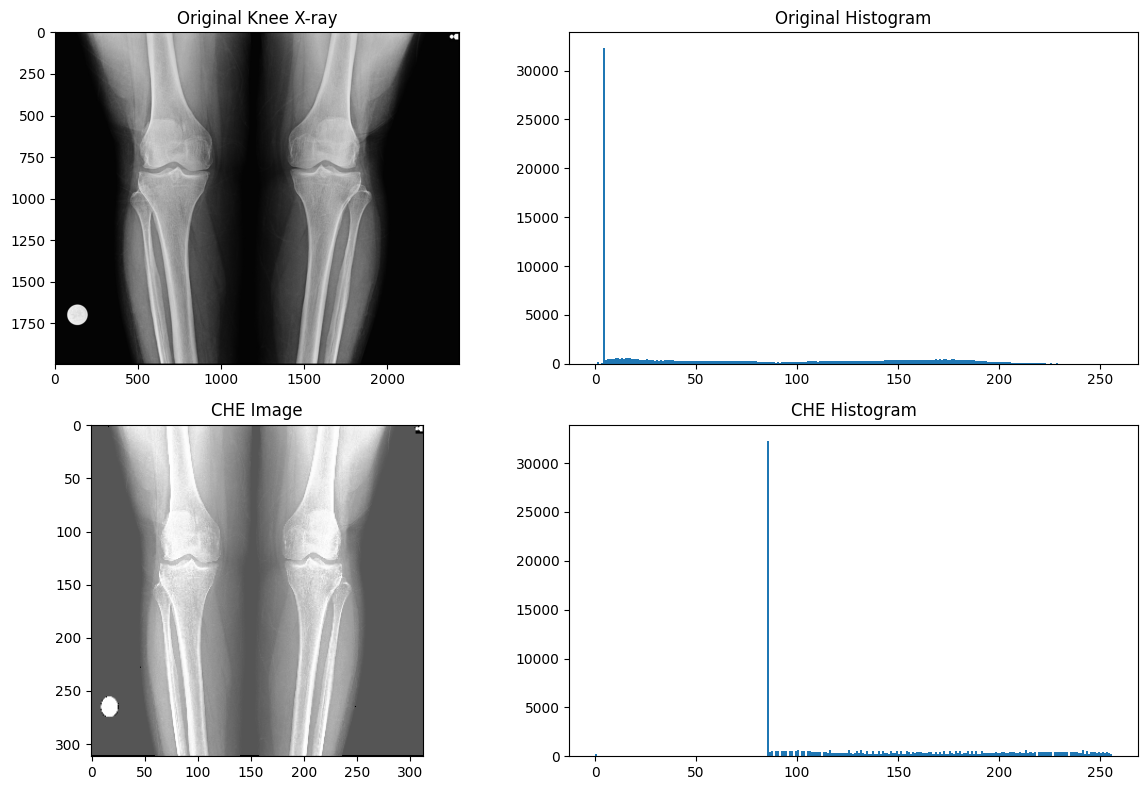

In [3]:
# Load a knee X-ray image in grayscale
img_org = cv2.imread('knee.jpg')

# Resize the image to 512x512
img_resize = cv2.resize(img_org, (312, 312))

img_gray = cv2.cvtColor(img_resize, cv2.COLOR_RGB2GRAY)

# Compute histogram and CDF
hist, bins = np.histogram(img_gray.flatten(), 256, [0, 256])
cdf = hist.cumsum()
cdf_min = cdf[cdf > 0].min()
M, N = img_gray.shape

# Perform CHE
cdf_normalized = np.round(((cdf - cdf_min) / (M * N - cdf_min) * 255)).astype(np.uint8)
img_che = cv2.LUT(img_gray, cdf_normalized)

# Save the result
cv2.imwrite('Cumulative_Histogram_Equalization_CHE/knee_original.jpg', img_org)
cv2.imwrite('Cumulative_Histogram_Equalization_CHE/knee_resized.jpg', img_resize)   
cv2.imwrite('Cumulative_Histogram_Equalization_CHE/knee_gray.jpg', img_gray)   
cv2.imwrite('Cumulative_Histogram_Equalization_CHE/che_knee.jpg', img_che)

# Plot the images and histograms
plt.figure(figsize=(12, 8))
plt.subplot(221), plt.imshow(img_org, cmap='gray'), plt.title('Original Knee X-ray')
plt.subplot(222), plt.hist(img_gray.ravel(), 256, [0, 256]), plt.title('Original Histogram')
plt.subplot(223), plt.imshow(img_che, cmap='gray'), plt.title('CHE Image')
plt.subplot(224), plt.hist(img_che.ravel(), 256, [0, 256]), plt.title('CHE Histogram')
plt.tight_layout()
plt.show()

## **Quadratic Dynamic Histogram Equalization (QDHE)**

QDHE is a spatial domain technique that enhances image contrast by manipulating the histogram in a dynamic and controlled manner. Unlike standard HE, which globally redistributes pixel intensities to achieve a uniform histogram, QDHE employs a multi-step process to partition the histogram, adjust bin heights, and apply localized HE, aiming to preserve brightness and reduce artifacts.

**Key Concept**

* Objective: QDHE seeks to enhance contrast while maintaining the natural appearance of the image, particularly in applications like medical imaging where brightness preservation is critical for diagnostic accuracy [3].
* Mechanism: The technique divides the histogram into sub-histograms based on statistical separators (e.g., medians), clips high-frequency bins to limit over-enhancement, reallocates gray levels dynamically, and applies HE to each sub-histogram.
* Context: QDHE addresses the over-enhancement and noise amplification issues of HE, making it suitable for images with non-uniform intensity distributions, such as medical radiographs [3].

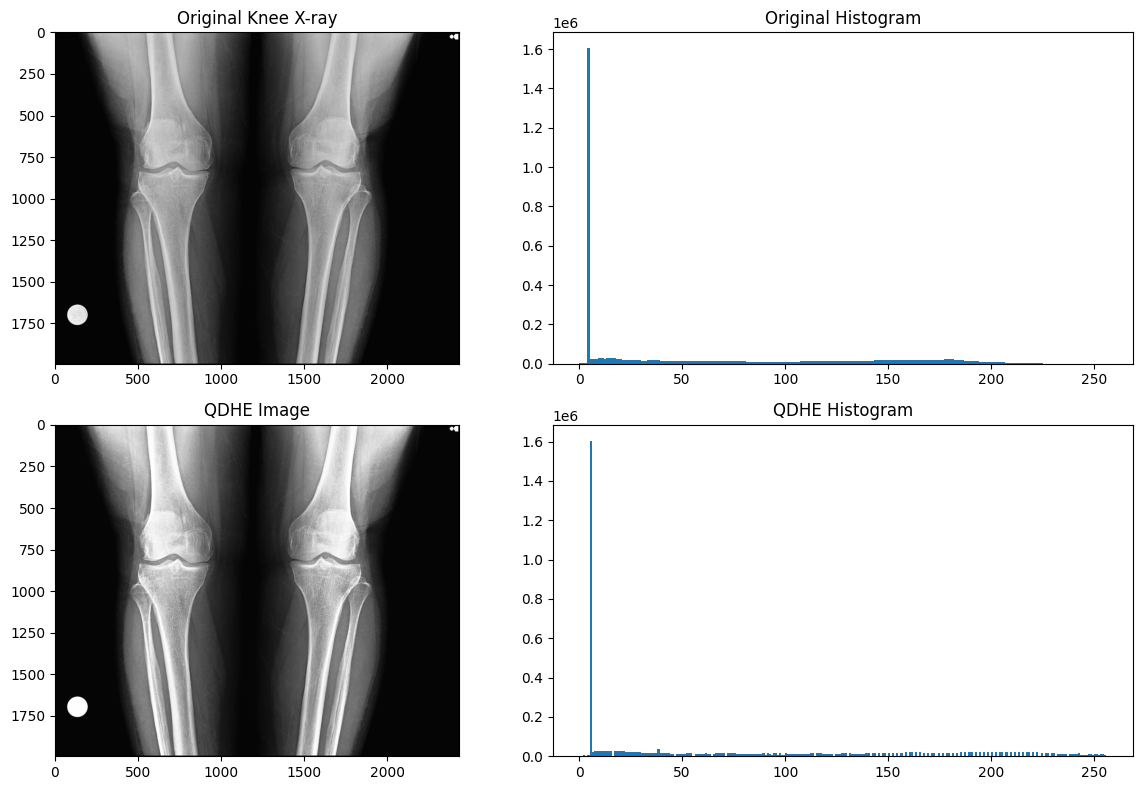

In [8]:
def qdhe(img):
    # Compute histogram
    hist, bins = np.histogram(img.flatten(), 256, [0, 256])
    M, N = img.shape
    total_pixels = M * N

    # Step 1: Histogram partitioning (median-based)
    cumsum = hist.cumsum()
    m1 = np.where(cumsum >= total_pixels * 0.25)[0][0]
    m2 = np.where(cumsum >= total_pixels * 0.5)[0][0]
    m3 = np.where(cumsum >= total_pixels * 0.75)[0][0]
    separators = [0, m1, m2, m3, 255]

    # Step 2: Clipping
    clip_limit = hist.mean()
    clipped_hist = np.clip(hist, 0, clip_limit)

    # Step 3: Gray level allocation
    output_img = np.zeros_like(img)
    for i in range(4):
        start, end = separators[i], separators[i+1]
        if start == end:
            continue
        sub_hist = clipped_hist[start:end]
        if sub_hist.sum() == 0:
            continue
        sub_cdf = sub_hist.cumsum()
        sub_cdf = sub_cdf / sub_cdf[-1] * (end - start) + start
        mapping = np.round(sub_cdf).astype(np.uint8)
        mask = (img >= start) & (img < end)
        output_img[mask] = mapping[img[mask] - start]

    return output_img

# Load a knee X-ray image in grayscale
img_org = cv2.imread('knee.jpg')
img = cv2.cvtColor(img_org, cv2.COLOR_RGB2GRAY)

# Perform QDHE
img_qdhe = qdhe(img)

# Save the result
cv2.imwrite('Quadratic_Dynamic_Histogram_Equalization_QDHE/knee_original.jpg', img_org)
cv2.imwrite('Quadratic_Dynamic_Histogram_Equalization_QDHE/knee_gray.jpg', img)
cv2.imwrite('Quadratic_Dynamic_Histogram_Equalization_QDHE/qdhe_knee.jpg', img_qdhe)

# Plot the images and histograms
plt.figure(figsize=(12, 8))
plt.subplot(221), plt.imshow(img, cmap='gray'), plt.title('Original Knee X-ray')
plt.subplot(222), plt.hist(img.ravel(), 256, [0, 256]), plt.title('Original Histogram')
plt.subplot(223), plt.imshow(img_qdhe, cmap='gray'), plt.title('QDHE Image')
plt.subplot(224), plt.hist(img_qdhe.ravel(), 256, [0, 256]), plt.title('QDHE Histogram')
plt.tight_layout()
plt.show()

## **Contrast-Limited Adaptive Histogram Equalization (CLAHE)**

CLAHE is a spatial domain technique that enhances image contrast by applying histogram equalization locally to small regions (tiles) of an image, rather than globally as in standard HE. It introduces a clipping mechanism to limit excessive contrast enhancement, making it robust against noise amplification, which is a common drawback of HE.

**Key Concept**

* Objective: CLAHE aims to enhance local contrast in images with non-uniform intensity distributions, such as medical radiographs, while preserving details and minimizing noise artifacts [1, 3].
* Mechanism: The image is divided into non-overlapping tiles, and HE is applied to each tile’s histogram after clipping high-frequency bins to a specified threshold. The results are interpolated across tile boundaries to ensure smooth transitions.
* Context: CLAHE is particularly effective for images where global HE would over-enhance uniform regions or amplify noise, such as in brain MRIs or retina scans [3].

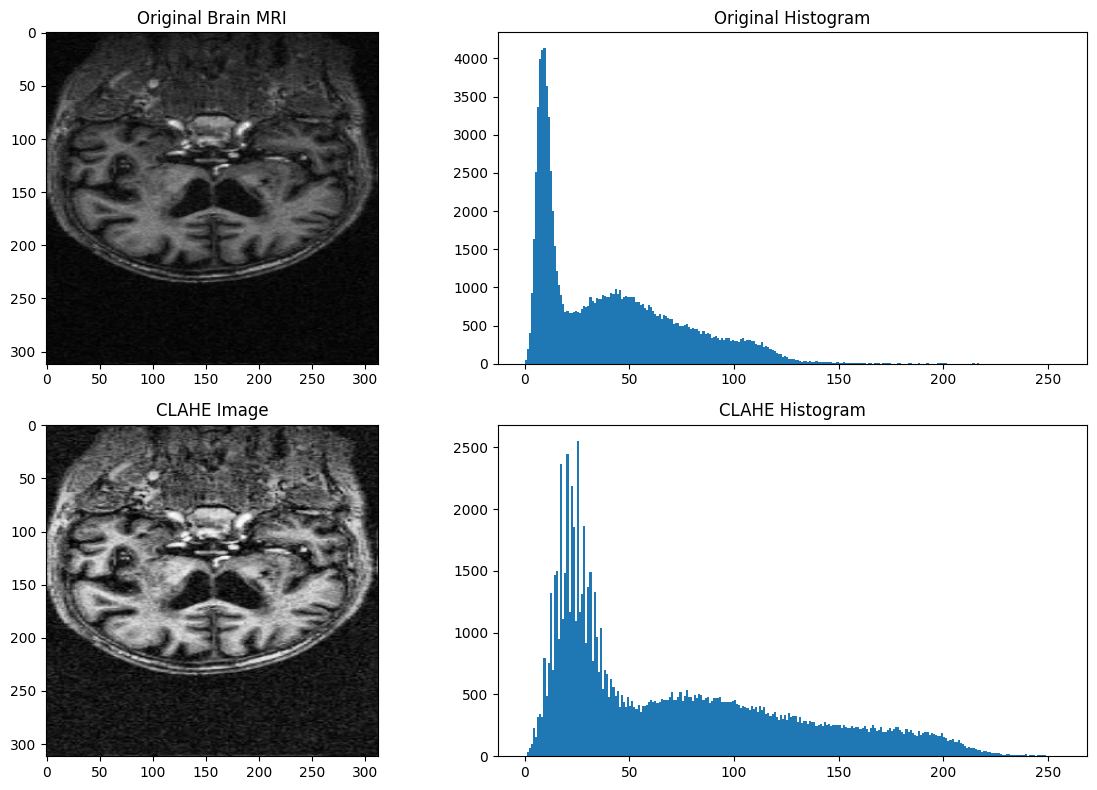

In [9]:
# Load a brain MRI image in grayscale
img_org = cv2.imread('brain_mri.jpg')
# Load a brain MRI image in grayscale
img_resize = cv2.resize(img_org, (312, 312))

img = cv2.cvtColor(img_resize, cv2.COLOR_RGB2GRAY)


# Apply CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img)

# Save the result
cv2.imwrite('Contrast-Limited_Adaptive_Histogram_Equalization_CLAHE/brain_mri_original.jpg', img_org)
cv2.imwrite('Contrast-Limited_Adaptive_Histogram_Equalization_CLAHE/brain_mri_resized.jpg', img_resize)
cv2.imwrite('Contrast-Limited_Adaptive_Histogram_Equalization_CLAHE/brain_mri_gray.jpg', img)
cv2.imwrite('Contrast-Limited_Adaptive_Histogram_Equalization_CLAHE/clahe_brain_mri.jpg', img_clahe)

# Plot the images and histograms
plt.figure(figsize=(12, 8))
plt.subplot(221), plt.imshow(img, cmap='gray'), plt.title('Original Brain MRI')
plt.subplot(222), plt.hist(img.ravel(), 256, [0, 256]), plt.title('Original Histogram')
plt.subplot(223), plt.imshow(img_clahe, cmap='gray'), plt.title('CLAHE Image')
plt.subplot(224), plt.hist(img_clahe.ravel(), 256, [0, 256]), plt.title('CLAHE Histogram')
plt.tight_layout()
plt.show()

## **Histogram Stretching**

Histogram stretching linearly scales pixel intensities to span the full dynamic range, improving contrast without altering the histogram shape [1]:

\[ s = \frac{(r - r_{\text{min}})}{(r_{\text{max}} - r_{\text{min}})} \times (L-1), \]

where \( r_{\text{min}} \) and \( r_{\text{max}} \) are the minimum and maximum intensity values.

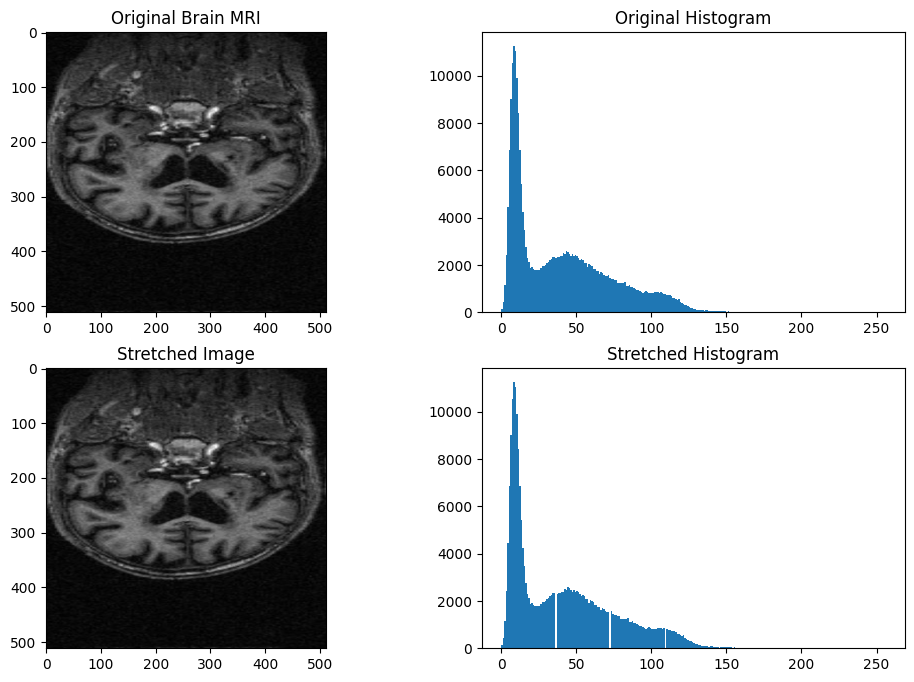

In [10]:
# Load a brain MRI image in grayscale
img_org = cv2.imread('brain_mri.jpg')
# Load a brain MRI image in grayscale
img_resize = cv2.resize(img_org, (512, 512))

img = cv2.cvtColor(img_resize, cv2.COLOR_RGB2GRAY)


# Compute min and max intensity values
min_val = np.min(img)
max_val = np.max(img)

# Perform histogram stretching
img_stretch = ((img - min_val) / (max_val - min_val) * 255).astype(np.uint8)

# Save the result
cv2.imwrite('Histogram_Stretching/brain_mri_original.jpg', img_org)
cv2.imwrite('Histogram_Stretching/brain_mri_resized.jpg', img_resize)
cv2.imwrite('Histogram_Stretching/brain_mri_gray.jpg', img)
cv2.imwrite('Histogram_Stretching/stretched_brain_mri.jpg', img_stretch)

# Plot the images and histograms
plt.figure(figsize=(12, 8))
plt.subplot(221);plt.imshow(img, cmap='gray');plt.title('Original Brain MRI');
plt.subplot(222);plt.hist(img.ravel(), 256, [0, 256]);plt.title('Original Histogram');
plt.subplot(223);plt.imshow(img_stretch, cmap='gray');plt.title('Stretched Image');
plt.subplot(224);plt.hist(img_stretch.ravel(), 256, [0, 256]);plt.title('Stretched Histogram');

## **Histogram Matching**

Histogram Stretching is a spatial domain technique that operates directly on pixel intensities to enhance contrast by linearly or non-linearly mapping the original intensity range to a wider range, typically spanning the full dynamic range of the display or processing system (e.g., [0, 255] for 8-bit grayscale images). Unlike Histogram Equalization (HE), which aims for a uniform histogram, Histogram Stretching preserves the shape of the original histogram while stretching it to cover the desired range.

**Key Concept**

* Objective: Enhance contrast by redistributing pixel intensities to make better use of the available intensity range, improving the visibility of image features without altering the relative distribution of intensities [1].
* Mechanism: The technique applies a linear or piecewise linear transformation to map the minimum and maximum intensities of the input image to the desired output range, effectively stretching the histogram.
* Context: Histogram Stretching is particularly useful for images with low contrast, where pixel intensities occupy a narrow range, such as medical radiographs or satellite images [3].

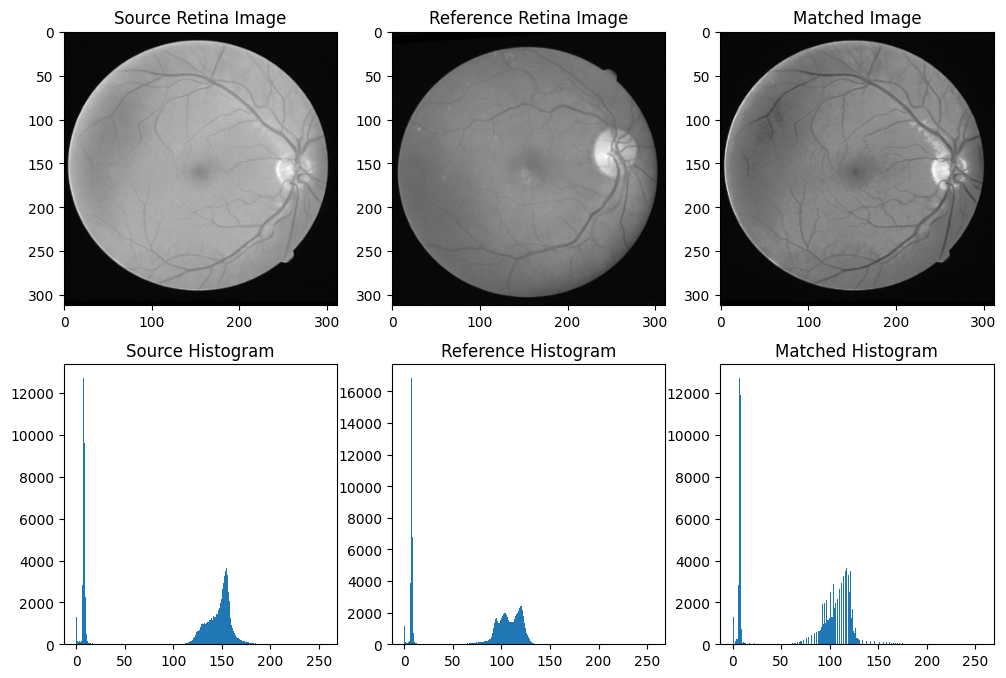

In [12]:
def histogram_matching(source, reference):
    # Compute histograms and CDFs
    source_hist, bins = np.histogram(source.flatten(), 256, [0, 256])
    ref_hist, bins = np.histogram(reference.flatten(), 256, [0, 256])
    source_cdf = source_hist.cumsum() / source_hist.sum()
    ref_cdf = ref_hist.cumsum() / ref_hist.sum()
    
    # Create mapping
    mapping = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        j = np.argmin(np.abs(ref_cdf - source_cdf[i]))
        mapping[i] = j
    
    # Apply mapping
    matched_image = cv2.LUT(source, mapping)
    return matched_image

# Load source and reference retina images in grayscale

source_org = cv2.imread('retina_source.jpg')
reference_org = cv2.imread('retina_reference.jpg')

# Resize images to the same size
source = cv2.resize(source_org, (312, 312)) 
reference = cv2.resize(reference_org, (312, 312))

source = cv2.cvtColor(source, cv2.COLOR_BGR2GRAY)
reference = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY)


# Perform histogram matching
img_matched = histogram_matching(source, reference)

# Save the result
cv2.imwrite('Histogram_Matching/retina_source_original.jpg', source_org)
cv2.imwrite('Histogram_Matching/retina_reference_original.jpg', reference_org) 
cv2.imwrite('Histogram_Matching/retina_source.jpg', source)
cv2.imwrite('Histogram_Matching/retina_reference.jpg', reference)
cv2.imwrite('Histogram_Matching/matched_retina.jpg', img_matched)

# Plot the images and histograms
plt.figure(figsize=(12, 8))
plt.subplot(231);plt.imshow(source, cmap='gray');plt.title('Source Retina Image');
plt.subplot(232);plt.imshow(reference, cmap='gray');plt.title('Reference Retina Image');
plt.subplot(233);plt.imshow(img_matched, cmap='gray');plt.title('Matched Image');
plt.subplot(234);plt.hist(source.ravel(), 256, [0, 256]);plt.title('Source Histogram');
plt.subplot(235);plt.hist(reference.ravel(), 256, [0, 256]);plt.title('Reference Histogram');
plt.subplot(236);plt.hist(img_matched.ravel(), 256, [0, 256]);plt.title('Matched Histogram');

## **Histogram Statistics**

Histogram Statistics involves extracting numerical descriptors from an image’s histogram, which represents the frequency distribution of pixel intensities (typically [0, 255] for 8-bit grayscale images). These descriptors summarize the image’s intensity characteristics, enabling quantitative analysis and decision-making in image processing pipelines.

**Key Concept**

* Objective: Quantify image properties such as mean intensity (brightness), variance (contrast), standard deviation (intensity spread), and higher-order moments (e.g., skewness, kurtosis) to support tasks like enhancement, segmentation, or classification [1].
* Mechanism: Compute statistical measures directly from the histogram or pixel intensities, leveraging the histogram’s representation of intensity frequencies to reduce computational complexity.
* Context: Histogram Statistics is particularly valuable in applications requiring objective analysis, such as medical imaging, where statistical measures inform diagnostic preprocessing or quality assessment [3].

In [19]:
# Load a brain MRI image in grayscale
img = cv2.imread('brain_mri.jpg', cv2.IMREAD_GRAYSCALE)

# Compute histogram
hist, bins = np.histogram(img.flatten(), 256, [0, 256])

# Calculate statistics
mean_intensity = np.mean(img)
variance = np.var(img)
sd = np.std(img)

print(f'Mean Intensity: {mean_intensity:.2f}')
print(f'Variance: {variance:.2f}')
print(f'Standard Deviation: {sd:.2f}')

Mean Intensity: 40.59
Variance: 1160.97
Standard Deviation: 34.07


## **Thresholding and Segmentation**

Thresholding is a segmentation technique that assigns pixels to distinct classes (e.g., object or background) based on their intensity values relative to one or more thresholds. Segmentation is the broader process of dividing an image into regions with similar properties, where thresholding is a key method, particularly when leveraging histogram-based analysis. These techniques rely on the image’s histogram to identify intensity levels that separate regions of interest.

**Key Concepts**
 
* Objective: Isolate objects from the background or partition an image into homogeneous regions to facilitate analysis, recognition, or measurement [1].
* Mechanism: Thresholding uses the histogram to identify intensity values (thresholds) that separate pixel populations, often based on peaks, valleys, or statistical criteria. Segmentation extends this by grouping pixels into regions using thresholding or other criteria [1].
* Context: These methods are particularly effective for images with distinct intensity distributions, such as medical radiographs or binary document images, where objects have different intensity characteristics from the background [3].

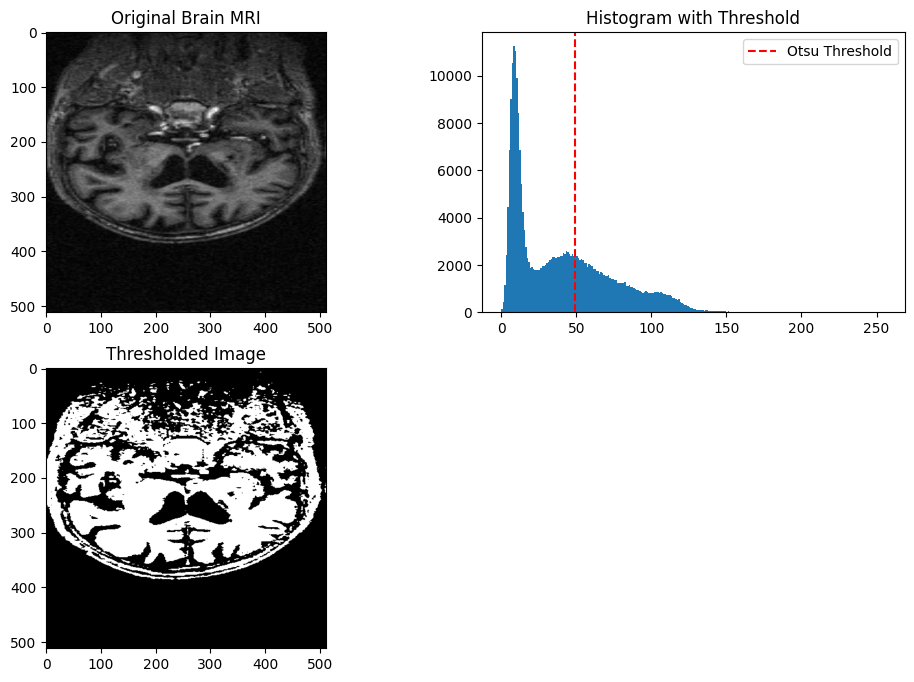

In [13]:
# Load a brain MRI image in grayscale
img_org = cv2.imread('brain_mri.jpg')
# Load a brain MRI image in grayscale
img_resize = cv2.resize(img_org, (512, 512))

img = cv2.cvtColor(img_resize, cv2.COLOR_RGB2GRAY)


# Apply Otsu's thresholding
_, img_thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Save the result
cv2.imwrite('Thresholding_and_Segmentation/brain_mri_original.jpg', img_org)
cv2.imwrite('Thresholding_and_Segmentation/brain_mri_resized.jpg', img_resize)
cv2.imwrite('Thresholding_and_Segmentation/brain_mri_gray.jpg', img)
cv2.imwrite('Thresholding_and_Segmentation/thresholded_brain_mri.jpg', img_thresh)

# Plot the images and histogram with threshold
plt.figure(figsize=(12, 8))
plt.subplot(221);plt.imshow(img, cmap='gray');plt.title('Original Brain MRI');
plt.subplot(222);plt.hist(img.ravel(), 256, [0, 256]);plt.axvline(x=_, color='r', linestyle='--', label='Otsu Threshold');plt.title('Histogram with Threshold');plt.legend();
plt.subplot(223);plt.imshow(img_thresh, cmap='gray');plt.title('Thresholded Image');


## **Practical Applications**

Histogram-based techniques are widely applied in medical imaging [3]:

- **Medical Imaging**: HE and CLAHE enhance contrast in brain MRIs, retina images, and mammograms, improving diagnostic accuracy.
- **Remote Sensing**: Histogram matching ensures consistent analysis of satellite images.
- **Computer Vision**: Histogram-based segmentation and statistics aid object detection in autonomous systems.

## **References**

[1] R. C. Gonzalez and R. E. Woods, *Digital Image Processing*, 4th ed. Pearson, 2018.

[2] N. Otsu, "A Threshold Selection Method from Gray-Level Histograms," *IEEE Transactions on Systems, Man, and Cybernetics*, vol. 9, no. 1, pp. 62--66, 1979.

[3] N. Salem, H. Malik, and A. Shams, "Medical image enhancement based on histogram algorithms," *Procedia Computer Science*, vol. 163, pp. 300--311, 2019.

[4] OpenCV, "OpenCV Documentation," [https://docs.opencv.org](https://docs.opencv.org), 2025.

[5] Kaggle, Images and Datasets.

[6] Grok AI, For for Structured data and information.